# Data Exploration - Bank Marketing Dataset

**Project**: Bank Marketing Campaign Prediction  
**Date**: Week 4, Day 19  
**Task**: Load dataset, explore structure, check missing values, visualize distributions

---

## Table of Contents
1. Import Libraries
2. Load Dataset
3. Basic Information
4. Missing Values Check
5. Target Distribution Analysis
6. Numerical Features Analysis
7. Categorical Features Analysis
8. Correlation Analysis
9. Summary and Insights

In [1]:
# %% 
# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Seaborn version: {sns.__version__}")

✅ Libraries imported successfully!
Pandas version: 2.3.1
NumPy version: 2.3.1
Seaborn version: 0.13.2


## 2. Load Dataset

In [2]:
# %%
# ============================================
# 2. LOAD DATASET
# ============================================

# Try to load from local file
try:
    df = pd.read_csv('../data/raw/bank-full.csv', sep=';')
    print("Dataset loaded from local file!")
    print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
except FileNotFoundError:
    print("Dataset not found in local folder.")
    print("Please download from: https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip")
    print("Extract and place 'bank-full.csv' in day-19/data/raw/")
    
    # Alternative: Load from OpenML
    try:
        from sklearn.datasets import fetch_openml
        X, y = fetch_openml('bank-marketing', version=1, return_X_y=True, as_frame=True)
        df = X.copy()
        df['y'] = y
        print("Dataset loaded from OpenML!")
        print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    except:
        print("\nCreating sample dataset for demonstration...")
        # Sample data to understand structure
        sample_data = {
            'age': [30, 45, 25, 50, 35, 60, 22, 48, 33, 55, 40, 28, 52, 38, 42],
            'job': ['admin', 'technician', 'services', 'management', 'retired', 
                    'admin', 'student', 'technician', 'management', 'services',
                    'blue-collar', 'admin', 'management', 'technician', 'retired'],
            'marital': ['married', 'single', 'married', 'divorced', 'married',
                        'single', 'single', 'married', 'divorced', 'married',
                        'married', 'single', 'married', 'divorced', 'married'],
            'education': ['university', 'university', 'high_school', 'university', 'university',
                          'high_school', 'university', 'university', 'high_school', 'university',
                          'basic.9y', 'university', 'university', 'high_school', 'university'],
            'default': ['no', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'no', 'no',
                        'no', 'no', 'no', 'no', 'no'],
            'housing': ['yes', 'no', 'yes', 'yes', 'yes', 'no', 'yes', 'yes', 'no', 'yes',
                        'yes', 'yes', 'no', 'yes', 'yes'],
            'loan': ['no', 'yes', 'no', 'no', 'no', 'no', 'yes', 'no', 'no', 'no',
                     'no', 'no', 'yes', 'no', 'no'],
            'contact': ['cellular', 'cellular', 'telephone', 'cellular', 'cellular',
                        'cellular', 'cellular', 'telephone', 'cellular', 'cellular',
                        'cellular', 'cellular', 'telephone', 'cellular', 'cellular'],
            'month': ['may', 'may', 'june', 'june', 'may', 'may', 'july', 'june', 'may', 'june',
                      'may', 'may', 'june', 'july', 'may'],
            'day_of_week': ['mon', 'tue', 'wed', 'thu', 'fri', 'mon', 'tue', 'wed', 'thu', 'fri',
                            'mon', 'tue', 'wed', 'thu', 'fri'],
            'duration': [200, 150, 300, 250, 180, 400, 100, 350, 220, 280,
                         190, 210, 320, 170, 260],
            'campaign': [1, 2, 3, 1, 2, 1, 4, 2, 1, 3, 2, 1, 3, 2, 1],
            'pdays': [999, 999, 999, 999, 999, 999, 999, 999, 999, 999,
                      999, 999, 999, 999, 999],
            'previous': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            'poutcome': ['none', 'none', 'none', 'none', 'none', 'none', 'none', 'none', 'none', 'none',
                         'none', 'none', 'none', 'none', 'none'],
            'emp_var_rate': [1.4, 1.4, -1.1, -1.1, 1.4, 1.4, -1.1, -1.1, 1.4, 1.4,
                             1.4, 1.4, -1.1, -1.1, 1.4],
            'cons_price_idx': [92.89, 92.89, 93.08, 93.08, 92.89, 92.89, 93.08, 93.08, 92.89, 92.89,
                               92.89, 92.89, 93.08, 93.08, 92.89],
            'cons_conf_idx': [-36.1, -36.1, -36.1, -36.1, -36.1, -36.1, -36.1, -36.1, -36.1, -36.1,
                              -36.1, -36.1, -36.1, -36.1, -36.1],
            'euribor3m': [4.86, 4.86, 4.86, 4.86, 4.86, 4.86, 4.86, 4.86, 4.86, 4.86,
                          4.86, 4.86, 4.86, 4.86, 4.86],
            'nr_employed': [5167.0, 5167.0, 5108.0, 5108.0, 5167.0, 5167.0, 5108.0, 5108.0, 5167.0, 5167.0,
                            5167.0, 5167.0, 5108.0, 5108.0, 5167.0],
            'y': ['no', 'no', 'yes', 'no', 'yes', 'no', 'no', 'yes', 'no', 'no',
                  'no', 'no', 'yes', 'no', 'no']
        }
        df = pd.DataFrame(sample_data)
        print(f"Created sample dataset: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded from local file!
Shape: 41188 rows × 21 columns
Memory usage: 26.80 MB


## 3. Basic Information

In [3]:
# %%
# ============================================
# 3. BASIC INFORMATION
# ============================================

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\nShape: {df.shape[0]} rows × {df.shape[1]} columns")

print(f"\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\nData Types:")
print(df.dtypes)

# %% 
print("\nFirst 5 rows:")
df.head()

# %%
print("\nLast 5 rows:")
df.tail()

DATASET OVERVIEW

Shape: 41188 rows × 21 columns

Column Names:
   1. age
   2. job
   3. marital
   4. education
   5. default
   6. housing
   7. loan
   8. contact
   9. month
  10. day_of_week
  11. duration
  12. campaign
  13. pdays
  14. previous
  15. poutcome
  16. emp.var.rate
  17. cons.price.idx
  18. cons.conf.idx
  19. euribor3m
  20. nr.employed
  21. y

Data Types:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

First 5 rows:

Last 5 rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


## 4. Missing Values Check

In [4]:
# %%
# ============================================
# 4. MISSING VALUES
# ============================================

print("=" * 60)
print("MISSING VALUES CHECK")
print("=" * 60)

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})

missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print("No missing values found in the dataset!")
else:
    print("Missing values found:")
    print(missing_df)

MISSING VALUES CHECK
No missing values found in the dataset!


## 5. Target Distribution Analysis

TARGET DISTRIBUTION

Target Distribution:
y
no     36548
yes     4640
Name: count, dtype: int64

Class Distribution:
  'no'  : 36,548 ( 88.7%)
  'yes' :  4,640 ( 11.3%)

This is an imbalanced dataset! Consider using class weights or SMOTE.


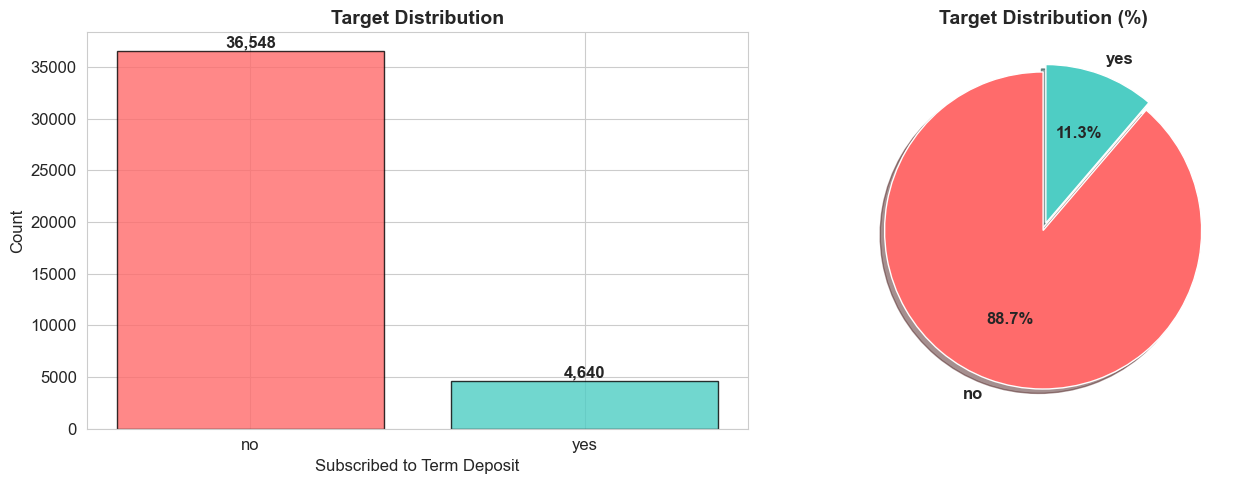

In [5]:
# %%
# ============================================
# 5. TARGET DISTRIBUTION
# ============================================

print("=" * 60)
print("TARGET DISTRIBUTION")
print("=" * 60)

target_counts = df['y'].value_counts()
print(f"\nTarget Distribution:")
print(target_counts)

print(f"\nClass Distribution:")
print(f"  'no'  : {target_counts['no']:>6,} ({target_counts['no']/len(df)*100:>5.1f}%)")
print(f"  'yes' : {target_counts['yes']:>6,} ({target_counts['yes']/len(df)*100:>5.1f}%)")

# Check if imbalanced
if target_counts['yes']/len(df) < 0.2:
    print("\nThis is an imbalanced dataset! Consider using class weights or SMOTE.")

# %%
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
colors = ['#FF6B6B', '#4ECDC4']
bars = axes[0].bar(target_counts.index, target_counts.values, color=colors, alpha=0.8, edgecolor='black')
axes[0].set_title('Target Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Subscribed to Term Deposit')
axes[0].set_ylabel('Count')

for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 50,
                f'{height:,.0f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index,
           autopct='%1.1f%%', colors=colors, startangle=90, explode=(0, 0.05),
           textprops={'fontsize': 12, 'fontweight': 'bold'}, shadow=True)
axes[1].set_title('Target Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/eda_plots/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Numerical Features Analysis


Numerical features (10):
  - age
  - duration
  - campaign
  - pdays
  - previous
  - emp.var.rate
  - cons.price.idx
  - cons.conf.idx
  - euribor3m
  - nr.employed

Summary Statistics:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


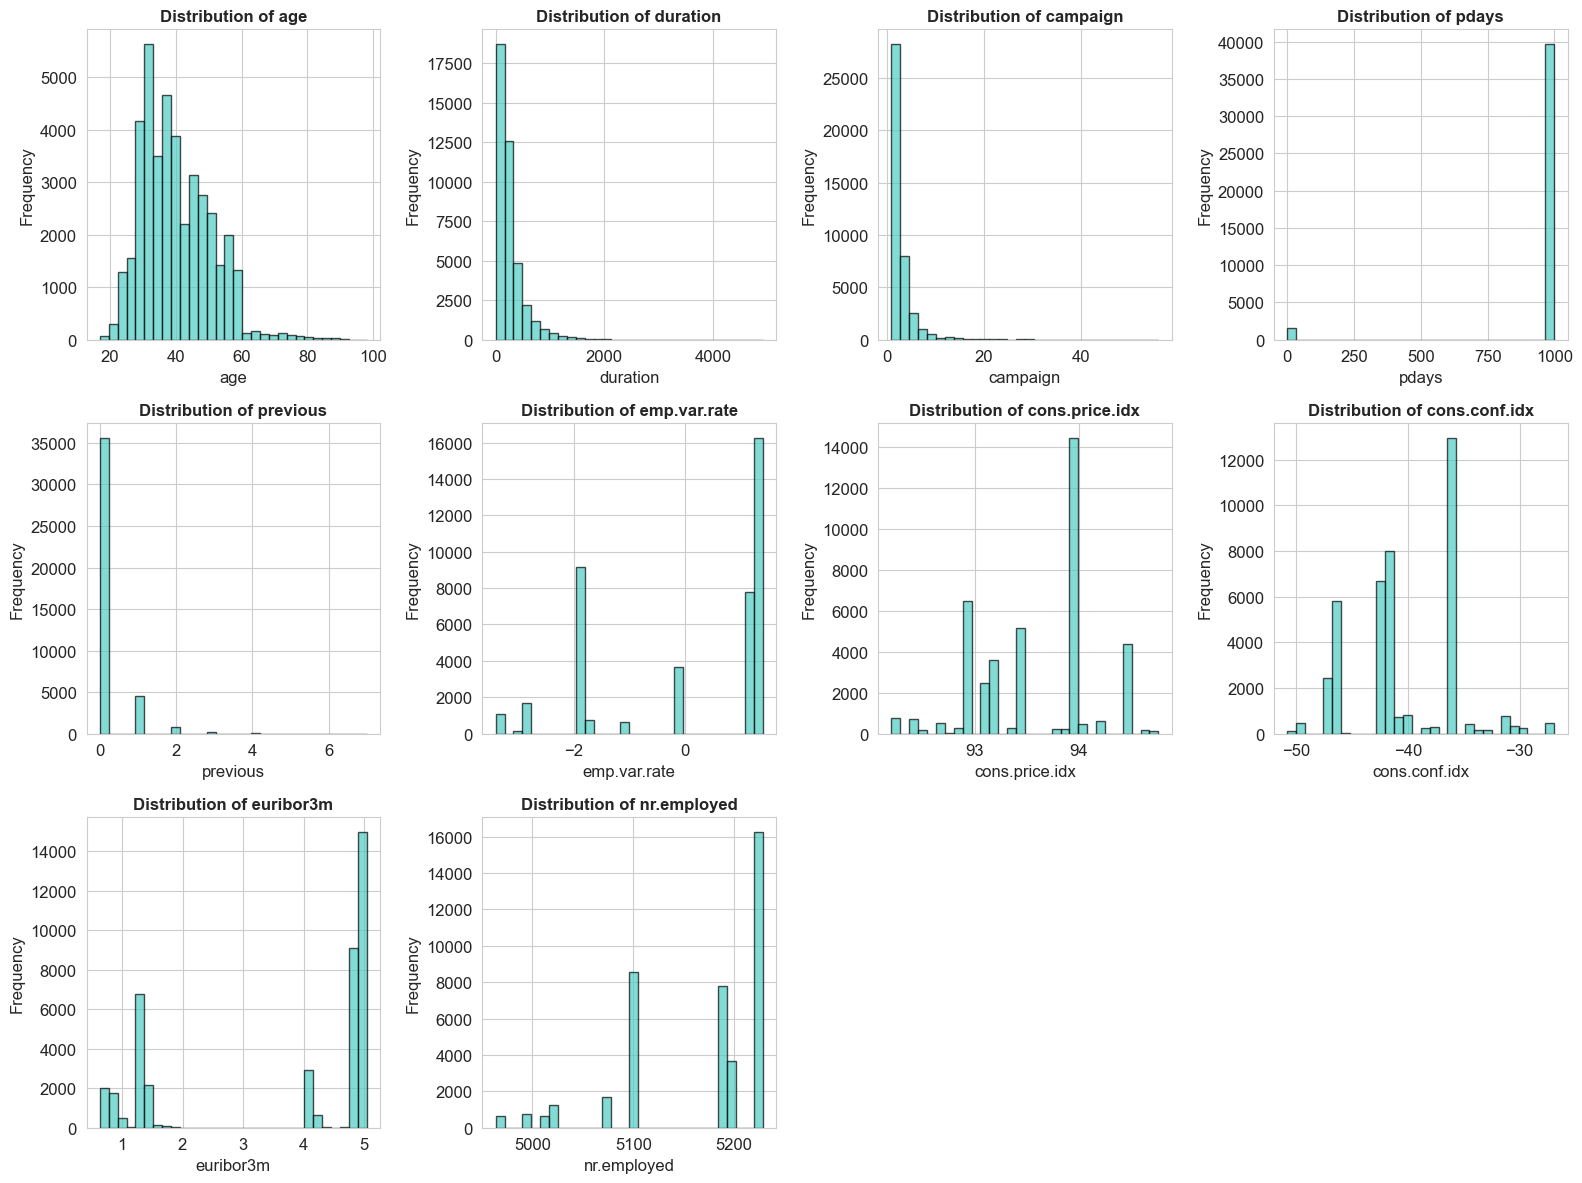

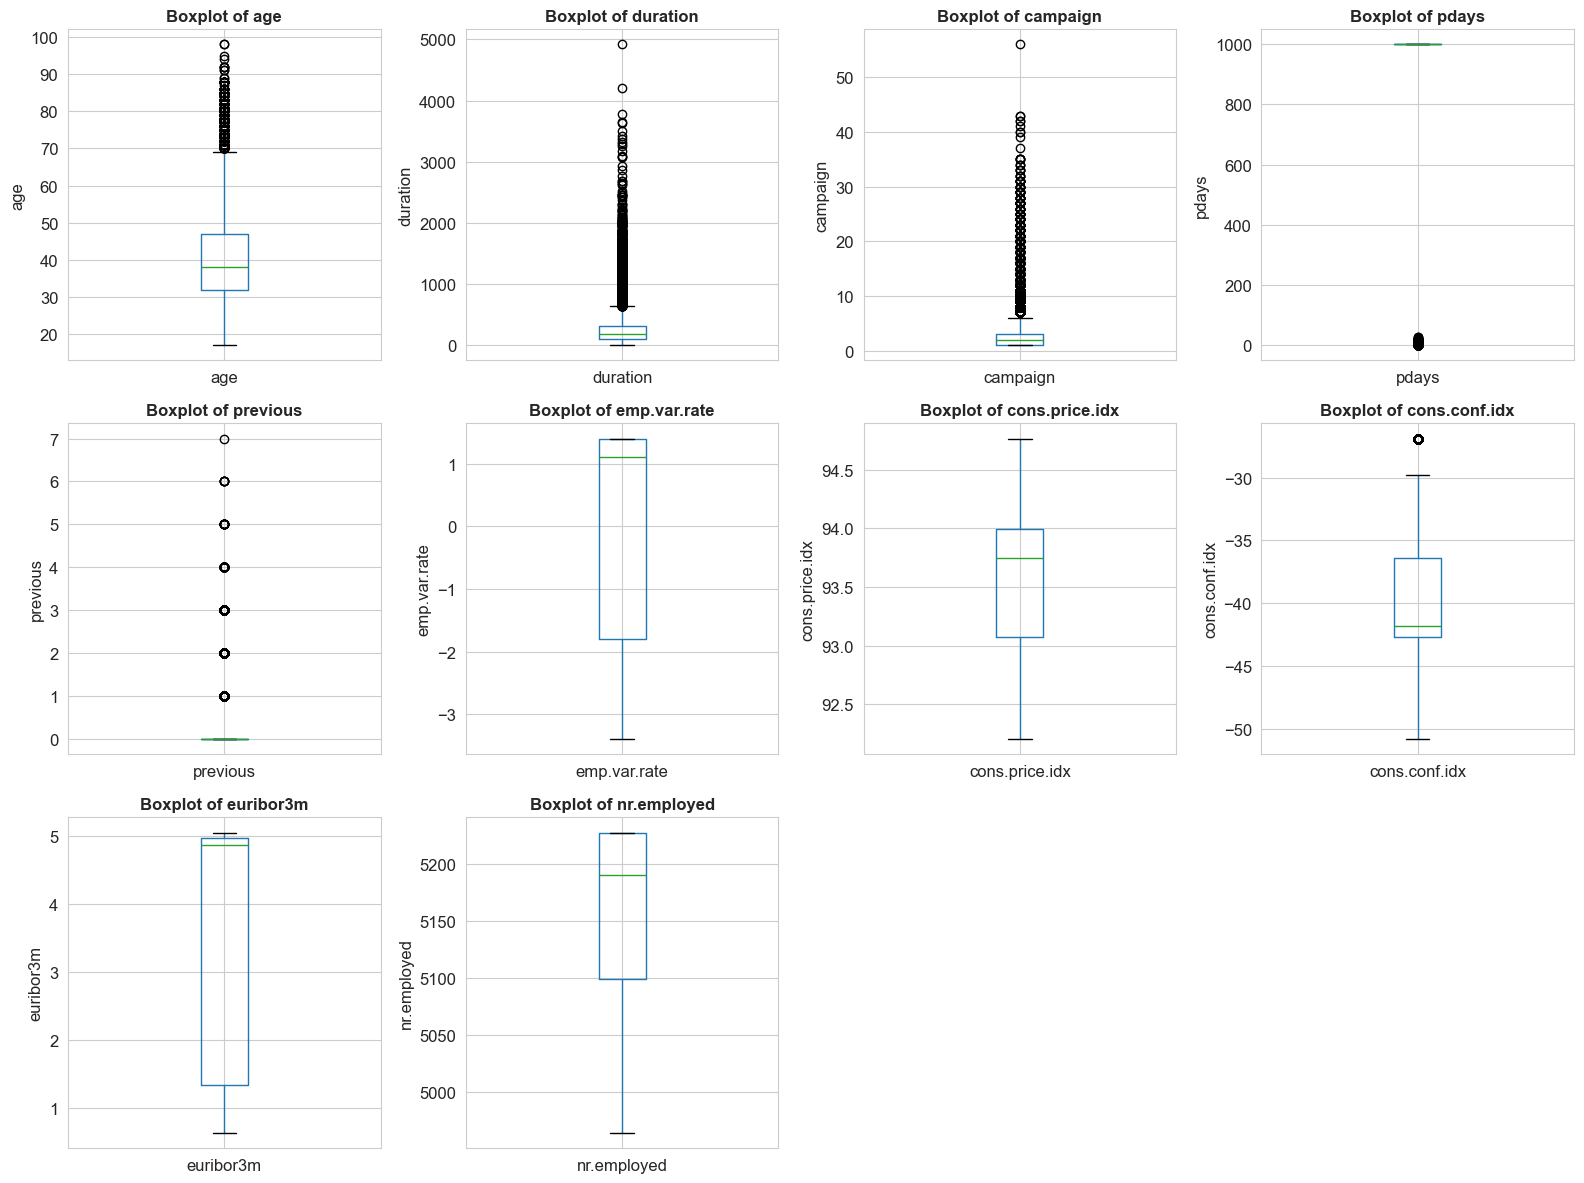

In [6]:
# %%
# ============================================
# 6. NUMERICAL FEATURES
# ============================================

# Identify numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"\nNumerical features ({len(numerical_cols)}):")
for col in numerical_cols:
    print(f"  - {col}")

# %%
# Summary statistics
print("\nSummary Statistics:")
display(df[numerical_cols].describe())

# %%
# Plot numerical features distributions
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    if i < len(axes):
        df[col].hist(bins=30, ax=axes[i], color='#4ECDC4', edgecolor='black', alpha=0.7)
        axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

# Hide empty subplots
for i in range(len(numerical_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/eda_plots/numerical_features.png', dpi=300, bbox_inches='tight')
plt.show()

# %%
# Box plots to check for outliers
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    if i < len(axes):
        df.boxplot(column=col, ax=axes[i])
        axes[i].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
        axes[i].set_ylabel(col)

for i in range(len(numerical_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/eda_plots/numerical_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Categorical Features Analysis


Categorical features (11):
  - job
  - marital
  - education
  - default
  - housing
  - loan
  - contact
  - month
  - day_of_week
  - poutcome
  - y

Unique values in categorical columns:

job: 12 unique values
  ['housemaid' 'services' 'admin.' 'blue-collar' 'technician']...

marital: 4 unique values
  ['married' 'single' 'divorced' 'unknown']...

education: 8 unique values
  ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course']...

default: 3 unique values
  ['no' 'unknown' 'yes']...

housing: 3 unique values
  ['no' 'yes' 'unknown']...

loan: 3 unique values
  ['no' 'yes' 'unknown']...

contact: 2 unique values
  ['telephone' 'cellular']...

month: 10 unique values
  ['may' 'jun' 'jul' 'aug' 'oct']...

day_of_week: 5 unique values
  ['mon' 'tue' 'wed' 'thu' 'fri']...

poutcome: 3 unique values
  ['nonexistent' 'failure' 'success']...

y: 2 unique values
  ['no' 'yes']...


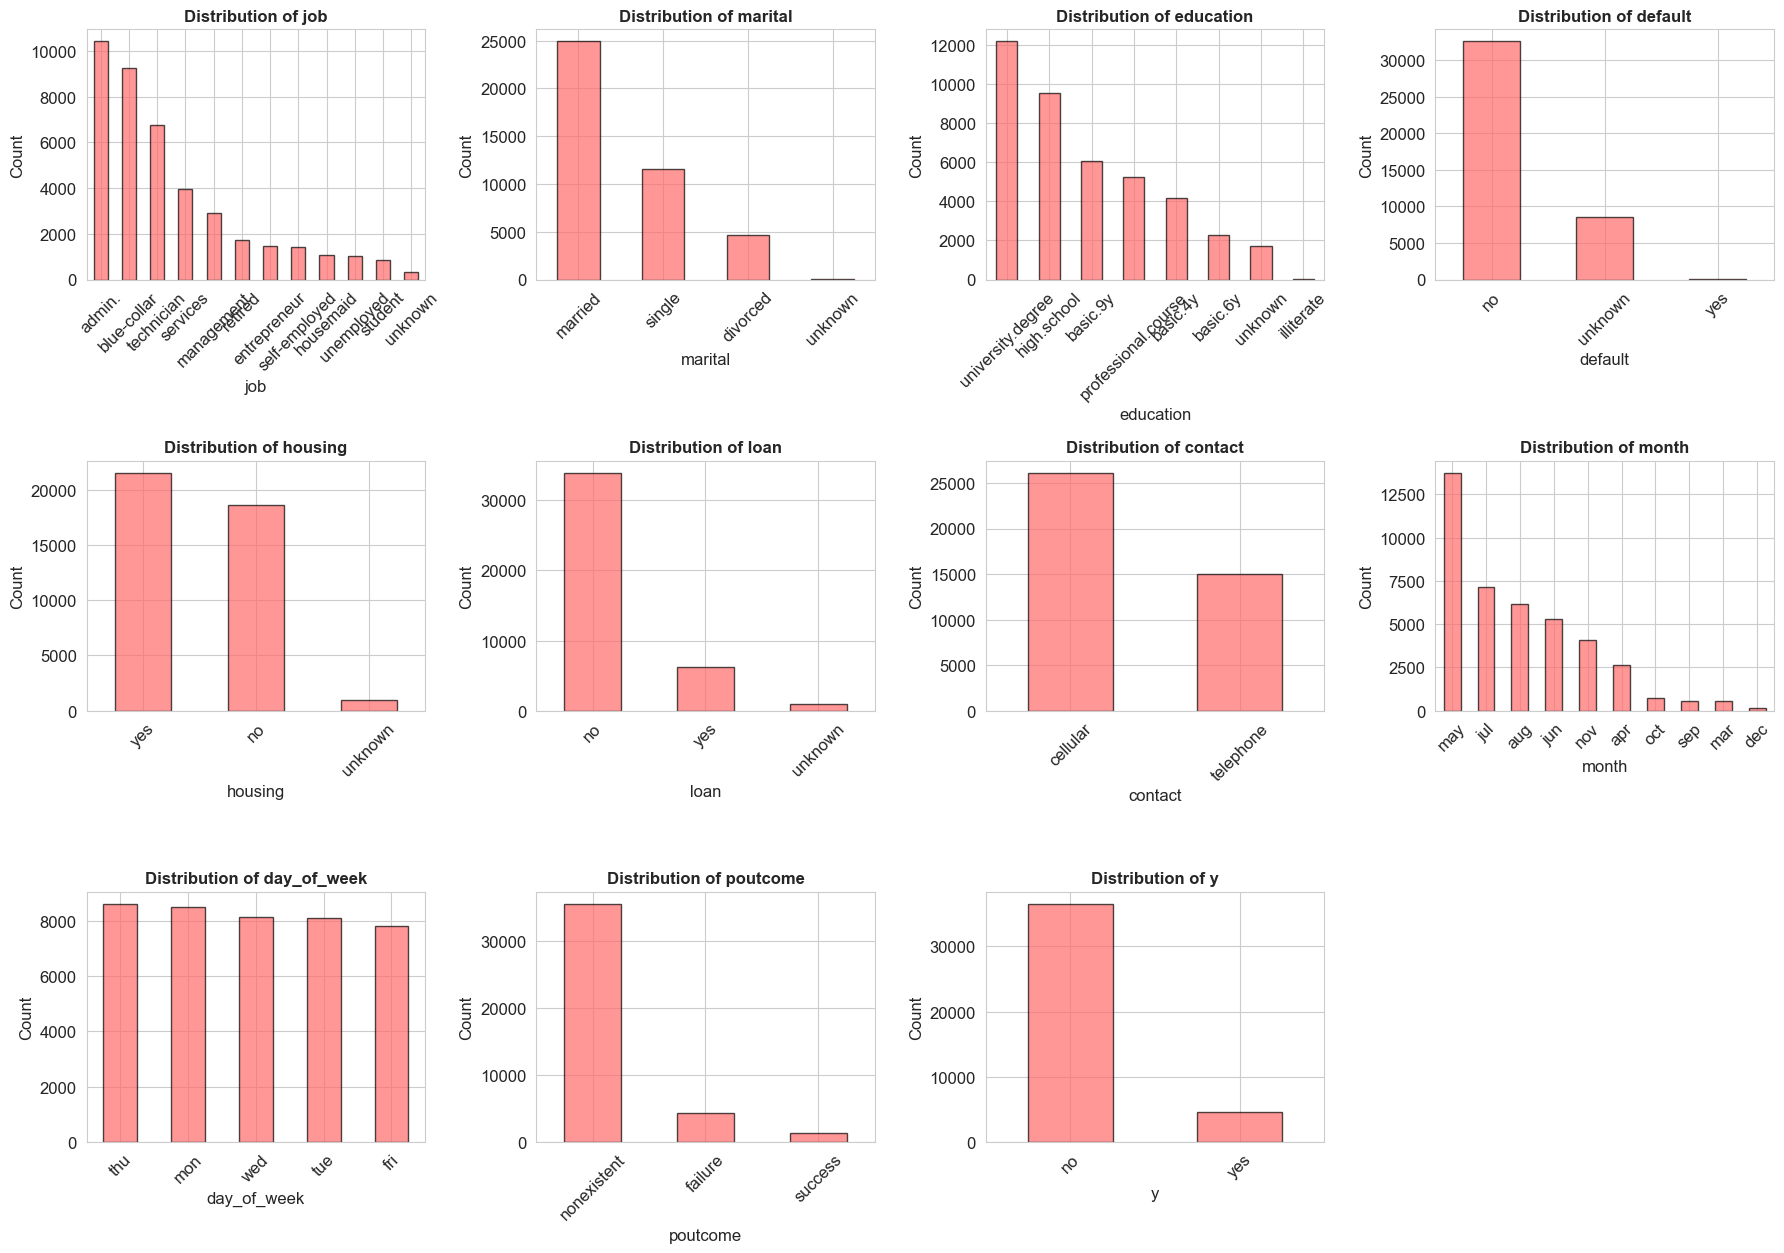

In [7]:
# %%
# ============================================
# 7. CATEGORICAL FEATURES
# ============================================

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical features ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"  - {col}")

# %%
# Check unique values in categorical columns
print("\nUnique values in categorical columns:")
for col in categorical_cols:
    unique_vals = df[col].unique()
    print(f"\n{col}: {len(unique_vals)} unique values")
    print(f"  {unique_vals[:5]}...")

# %%
# Visualize categorical features
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    if i < len(axes):
        value_counts = df[col].value_counts()
        value_counts.plot(kind='bar', ax=axes[i], color='#FF6B6B', alpha=0.7, edgecolor='black')
        axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

for i in range(len(categorical_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/eda_plots/categorical_features.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Correlation Analysis

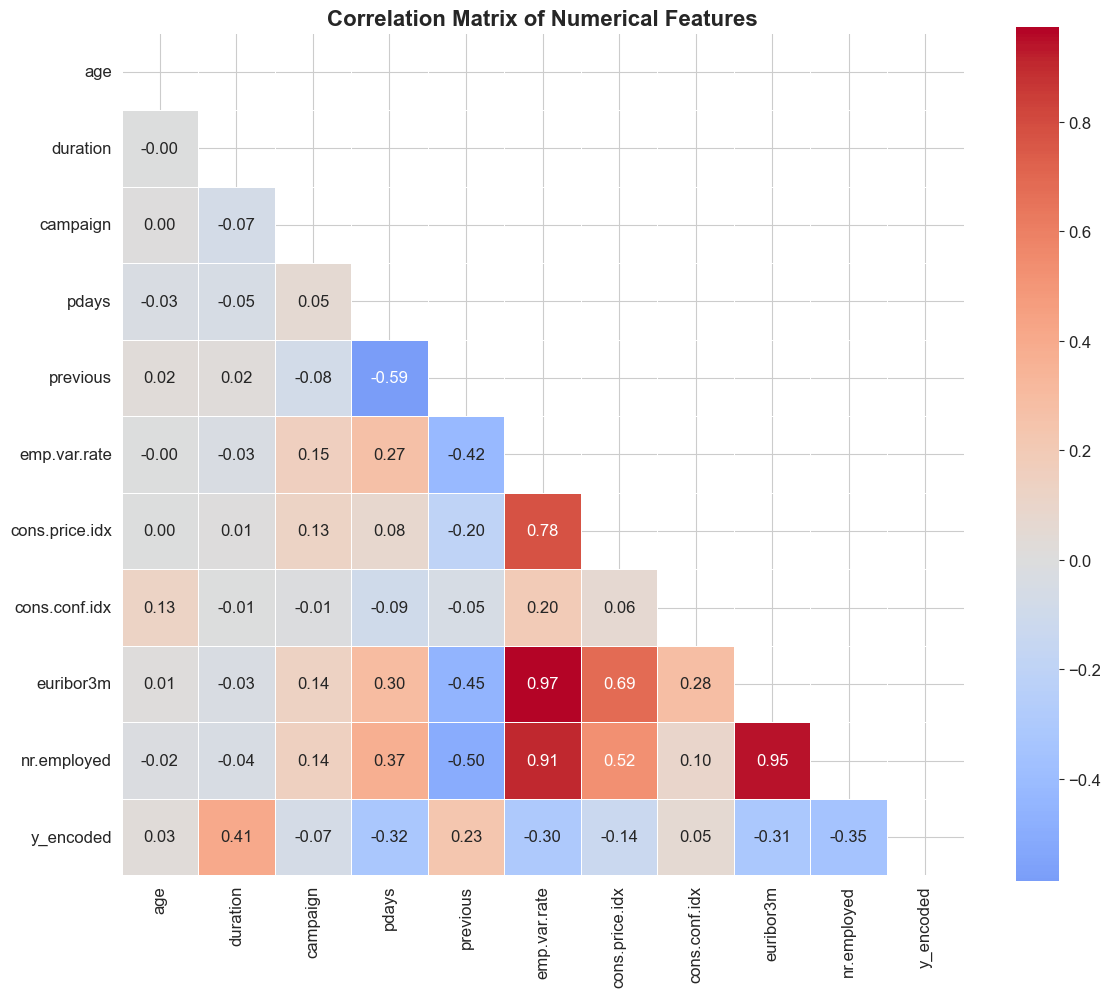


Correlation with target:
duration          0.405274
previous          0.230181
cons.conf.idx     0.054878
age               0.030399
campaign         -0.066357
cons.price.idx   -0.136211
emp.var.rate     -0.298334
euribor3m        -0.307771
pdays            -0.324914
nr.employed      -0.354678
Name: y_encoded, dtype: float64


In [8]:
# %%
# ============================================
# 8. CORRELATION ANALYSIS
# ============================================

# Encode target for correlation
df_encoded = df.copy()
df_encoded['y_encoded'] = df_encoded['y'].map({'yes': 1, 'no': 0})

# Calculate correlation with target
correlation_matrix = df_encoded[numerical_cols + ['y_encoded']].corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', 
            center=0, fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/eda_plots/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# %% 
# Correlation with target
print("\nCorrelation with target:")
corr_with_target = correlation_matrix['y_encoded'].drop('y_encoded').sort_values(ascending=False)
print(corr_with_target)

## 9. Summary and Key Insights

In [9]:
# %%
# ============================================
# 9. SUMMARY AND KEY INSIGHTS
# ============================================

print("=" * 60)
print("SUMMARY AND KEY INSIGHTS")
print("=" * 60)

print("\nDataset Summary:")
print(f"  - Total samples: {df.shape[0]:,}")
print(f"  - Total features: {df.shape[1]}")
print(f"  - Numerical features: {len(numerical_cols)}")
print(f"  - Categorical features: {len(categorical_cols)}")

print("\nTarget Variable Analysis:")
print(f"  - Class imbalance: {target_counts['yes']/len(df)*100:.1f}% positive")
print(f"  - Imbalance ratio: {target_counts['no']/target_counts['yes']:.1f}:1")

print("\nKey Observations:")
print("  1. No missing values in the dataset")
print("  2. Target variable is imbalanced (needs handling)")
print("  3. Features like 'duration' might cause data leakage")
print("  4. Mix of categorical and numerical features")

print("\nNext Steps:")
print("  1. Feature engineering and preprocessing")
print("  2. Handle class imbalance")
print("  3. Train baseline model")
print("  4. Compare advanced models")

# Save summary to file
with open('../reports/Day19_EDA_Summary.txt', 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("DAY 19 - EDA SUMMARY\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns\n\n")
    f.write(f"Target Distribution:\n")
    f.write(f"  no:  {target_counts['no']:>6,} ({target_counts['no']/len(df)*100:>5.1f}%)\n")
    f.write(f"  yes: {target_counts['yes']:>6,} ({target_counts['yes']/len(df)*100:>5.1f}%)\n\n")
    f.write(f"Numerical Features: {len(numerical_cols)}\n")
    f.write(f"Categorical Features: {len(categorical_cols)}\n")
    
print("\nEDA completed successfully!")

SUMMARY AND KEY INSIGHTS

Dataset Summary:
  - Total samples: 41,188
  - Total features: 21
  - Numerical features: 10
  - Categorical features: 11

Target Variable Analysis:
  - Class imbalance: 11.3% positive
  - Imbalance ratio: 7.9:1

Key Observations:
  1. No missing values in the dataset
  2. Target variable is imbalanced (needs handling)
  3. Features like 'duration' might cause data leakage
  4. Mix of categorical and numerical features

Next Steps:
  1. Feature engineering and preprocessing
  2. Handle class imbalance
  3. Train baseline model
  4. Compare advanced models

EDA completed successfully!
